导包

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.backends.backend_agg import FigureCanvasAgg
import dm_env
from dm_env import specs
from typing import Optional

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

仿照JAX

In [2]:
BOUNDS_X = np.array([-1., 1.], dtype=np.float32)
BOUNDS_Y = np.array([-1., 1.], dtype=np.float32)

DPI = 200
RENDER_HEIGHT_INCHES = 5

class Point2D(dm_env.Environment):
  def __init__(self):
    self._cur_pos = np.zeros(2, dtype=np.float32)
    self._goal_pos = np.zeros(2, dtype=np.float32)
    self._cur_vel = np.zeros(2, dtype=np.float32)
    self._cur_episode_traj = []
    self._physics_substeps = 10
    self._success_radius = 0.15

  def sample_goal(self):
    border_x = (BOUNDS_X[1] - BOUNDS_X[0]) * 0.05
    border_y = (BOUNDS_Y[1] - BOUNDS_Y[0]) * 0.05
    goal_x = np.random.uniform(
        BOUNDS_X[0] + border_x, BOUNDS_X[1] - border_x)
    goal_y = np.random.uniform(
        BOUNDS_Y[0] + border_y, BOUNDS_Y[1] - border_y)
    return np.array([goal_x, goal_y], dtype=np.float32)

  def set_goal(self, goal_pos):
    self._goal_pos = goal_pos

  def reset(self):
    self._goal_pos = self.sample_goal()
    cur_x = np.random.uniform(BOUNDS_X[0], BOUNDS_X[1])
    cur_y = np.random.uniform(BOUNDS_Y[0], BOUNDS_Y[1])
    self._cur_pos = np.array([cur_x, cur_y], dtype=np.float32)
    cur_pos_copy = self._cur_pos.copy()

    self._cur_vel = np.zeros(2, dtype=np.float32)
    cur_vel_copy = self._cur_vel.copy()

    obs = {
        'cur_pos': cur_pos_copy,
        'cur_vel': cur_vel_copy,
        'goal_pos': self._goal_pos.copy()}
    ts = dm_env.TimeStep(
        step_type=dm_env.StepType.FIRST,
        reward=None,
        discount=None,
        observation=obs,)

    self._cur_episode_traj = [cur_pos_copy]
    return ts

  def step(self, action):
    for i in range(self._physics_substeps):
      self._cur_vel += action
      self._cur_pos += self._cur_vel

    cur_pos_copy = self._cur_pos.copy()
    cur_vel_copy = self._cur_vel.copy()
    obs = {
        'cur_pos': cur_pos_copy,
        'cur_vel': cur_vel_copy,
        'goal_pos': self._goal_pos.copy()}

    if self.success():
      step_type = dm_env.StepType.LAST
    else:
      step_type = dm_env.StepType.MID
    ts = dm_env.TimeStep(
        step_type=step_type,
        reward=-1. * np.linalg.norm(self._cur_pos - self._goal_pos),
        discount=1.,
        observation=obs,)

    self._cur_episode_traj.append(cur_pos_copy)
    return ts

  def success(self, waypoint: Optional[np.ndarray] = None):
    if waypoint is not None:
      goal_pos = waypoint
    else:
      goal_pos = self._goal_pos
    return np.linalg.norm(self._cur_pos - goal_pos) < self._success_radius

  def observation_spec(self):
    return {
        'cur_pos': specs.Array((2,), dtype=np.float32),
        'cur_vel': specs.Array((2,), dtype=np.float32),
        'goal_pos': specs.Array((2,), dtype=np.float32),}

  def action_spec(self):
    return specs.Array((2,), dtype=np.float32)

  def render(
      self,
      title: str = '',
      points: Optional[np.ndarray] = None,
      goal_pos: Optional[np.ndarray] = None):
    fig, ax = plt.subplots(
        figsize=(RENDER_HEIGHT_INCHES, RENDER_HEIGHT_INCHES), dpi=DPI)
    ax.set_xlim(BOUNDS_X[0], BOUNDS_X[1])
    ax.set_ylim(BOUNDS_Y[0], BOUNDS_Y[1])
    ax.set_aspect('equal')

    if points is None:
      points = np.array(self._cur_episode_traj)
      cur_pos = self._cur_pos
    else:
      cur_pos = points[-1]

    if goal_pos is None:
      goal_pos = self._goal_pos

    ax.plot(points[:, 0], points[:, 1], marker='.', color='blue', markersize=16, linewidth=4)
    ax.scatter(
        goal_pos[0], goal_pos[1], marker='*', s=200, color='orange', linewidths=8)
    ax.scatter(
        cur_pos[0], cur_pos[1], marker='o', s=100, color='red', linewidths=8)

    # Add a dashed circle around the star
    circle = patches.Circle(
        (goal_pos[0], goal_pos[1]),  # Center of the circle
        self._success_radius,  # Radius of the circle
        edgecolor='green',  # Color of the circle
        linestyle='--',  # Dashed line
        linewidth=4,  # Thickness of the circle line
        fill=False  # Ensure it's just an outline
    )
    ax.add_patch(circle)  # Add the circle to the plot

    # Make the axes lines thicker
    for spine in ax.spines.values():
        spine.set_linewidth(4)  # Adjust the thickness here

    if title != '':
      ax.set_title(title, fontsize=18, fontweight='bold')

    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()

    # Render the plot using FigureCanvasAgg
    canvas = FigureCanvasAgg(fig)
    canvas.draw()

    # Convert the rendered image to a numpy array
    width, height = fig.get_size_inches() * fig.get_dpi()

    # 方法已经移除
    '''
    image = np.frombuffer(canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(int(height), int(width), 3)
    '''

    buf = canvas.buffer_rgba()
    image = np.asarray(buf)
    image = image[..., :3]  # 取 RGB 通道，去掉 alpha

    plt.close(fig)
    return image

In [3]:
env = Point2D()
ts = env.reset()
img = env.render()
print("Image shape:", img.shape)

Image shape: (1000, 1000, 3)


In [4]:
def pd_controller(cur_pos, cur_vel, goal_pos):
  Kp = 0.0002
  Kd = 0.0125
  act = Kp * (goal_pos - cur_pos) + Kd * (-1. * cur_vel)
  return act

In [5]:
from typing import Any, NamedTuple
import numpy as np

NestedArray = Any

class DataTuple(NamedTuple):
    observation: NestedArray
    action: NestedArray
    time_to_success: NestedArray
    reward: NestedArray
    discount: NestedArray
    next_observation: NestedArray

In [6]:
def generate_dataset(env, pd_controller, num_episodes=10000, num_waypoints_per_episode=5, episode_len_discard_thresh=10):
    episodes = []
    
    while len(episodes) < num_episodes:
        traj = []
        ts = env.reset()
        cur_obs = ts.observation
        succ = env.success()

        waypoint_idx = 0
        if num_waypoints_per_episode == 0:
            cur_waypoint = cur_obs['goal_pos']
        else:
            cur_waypoint = env.sample_goal()
        waypoint_succ = env.success(waypoint=cur_waypoint)

        while not succ:
            if waypoint_succ:
                waypoint_idx += 1
                waypoint_idx = min(waypoint_idx, num_waypoints_per_episode)
                if waypoint_idx == num_waypoints_per_episode:
                    cur_waypoint = cur_obs['goal_pos']
                else:
                    cur_waypoint = env.sample_goal()

            act = pd_controller(cur_obs['cur_pos'], cur_obs['cur_vel'], cur_waypoint)
            ts = env.step(act)
            next_obs = ts.observation

            traj.append({
                'observation': cur_obs,
                'action': act,
                'reward': ts.reward if ts.reward is not None else 0.0,
                'discount': 1.0,
                'next_observation': next_obs,
            })

            cur_obs = next_obs
            succ = env.success()
            waypoint_succ = env.success(waypoint=cur_waypoint)

        # 添加最后一步（discount=0）
        act = pd_controller(cur_obs['cur_pos'], cur_obs['cur_vel'], cur_waypoint)
        traj.append({
            'observation': cur_obs,
            'action': act,
            'reward': ts.reward if ts.reward is not None else 0.0,
            'discount': 0.0,
            'next_observation': cur_obs,
        })

        # 丢弃过短的 episode
        traj_len = len(traj)
        if traj_len < episode_len_discard_thresh:
            continue

        # 将列表转换为 numpy 数组堆叠
        # 注意：observation 和 next_observation 是字典，需要先展平成向量
        obs_list = []
        act_list = []
        reward_list = []
        discount_list = []
        next_obs_list = []

        for step in traj:
            obs_vec = np.concatenate([step['observation']['cur_pos'], 
                                      step['observation']['cur_vel'], 
                                      step['observation']['goal_pos']])
            next_obs_vec = np.concatenate([step['next_observation']['cur_pos'],
                                           step['next_observation']['cur_vel'],
                                           step['next_observation']['goal_pos']])
            obs_list.append(obs_vec)
            act_list.append(step['action'])
            reward_list.append(step['reward'])
            discount_list.append(step['discount'])
            next_obs_list.append(next_obs_vec)

        # 堆叠成数组
        obs_arr = np.stack(obs_list, axis=0).astype(np.float32)
        act_arr = np.stack(act_list, axis=0).astype(np.float32)
        reward_arr = np.array(reward_list, dtype=np.float32)
        discount_arr = np.array(discount_list, dtype=np.float32)
        next_obs_arr = np.stack(next_obs_list, axis=0).astype(np.float32)

        # 计算 time_to_success（从后往前递减）
        time_to_success_arr = np.arange(traj_len - 1, -1, -1, dtype=np.float32)

        # 保存为 DataTuple
        ep_tuple = DataTuple(
            observation=obs_arr,
            action=act_arr,
            time_to_success=time_to_success_arr,
            reward=reward_arr,
            discount=discount_arr,
            next_observation=next_obs_arr,
        )
        episodes.append(ep_tuple)

    # 将所有 episodes 拼接成一个大数组
    all_obs = np.concatenate([ep.observation for ep in episodes], axis=0)
    all_act = np.concatenate([ep.action for ep in episodes], axis=0)
    all_time = np.concatenate([ep.time_to_success for ep in episodes], axis=0)
    all_reward = np.concatenate([ep.reward for ep in episodes], axis=0)
    all_discount = np.concatenate([ep.discount for ep in episodes], axis=0)
    all_next_obs = np.concatenate([ep.next_observation for ep in episodes], axis=0)

    all_tuples = DataTuple(
        observation=all_obs,
        action=all_act,
        time_to_success=all_time,
        reward=all_reward,
        discount=all_discount,
        next_observation=all_next_obs,
    )

    # 打印统计信息
    print(f"Num Episodes: {len(episodes)}")
    lens = [ep.observation.shape[0] for ep in episodes]
    print(f"Episode Lens: mean={np.mean(lens):.2f}, std={np.std(lens):.2f}")
    print(f"Max Episode Len: {np.max(lens)}")
    print(f"Min Episode Len: {np.min(lens)}")

    return episodes, all_tuples

In [7]:
episodes, all_tuples = generate_dataset(env, pd_controller, num_episodes=100)
print("all_tuples.observation.shape:", all_tuples.observation.shape)

Num Episodes: 100
Episode Lens: mean=79.43, std=26.57
Max Episode Len: 123
Min Episode Len: 10
all_tuples.observation.shape: (7943, 6)


In [8]:
class PolicyNet(nn.Module):
    def __init__(self, obs_dim=6, act_dim=2, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))
    
    def forward(self, obs):
        features = self.net(obs)
        mean = self.mean_head(features)
        std = torch.exp(self.log_std.clamp(-20, 2))  # 限制范围防止数值问题
        return mean, std

class StepsNet(nn.Module):
    def __init__(self, obs_dim=6, num_steps=200, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_steps)  # 输出 logits
        )
    
    def forward(self, obs):
        return self.net(obs)

In [9]:
def train_sft(obs, actions, steps_labels, 
              num_epochs=10, batch_size=64, lr=1e-3, device='cpu'):
    # 转换为 tensor
    obs_t = torch.tensor(obs, dtype=torch.float32).to(device)
    acts_t = torch.tensor(actions, dtype=torch.float32).to(device)
    steps_t = torch.tensor(steps_labels, dtype=torch.long).to(device)
    
    dataset = TensorDataset(obs_t, acts_t, steps_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    policy = PolicyNet().to(device)
    steps_net = StepsNet().to(device)
    optimizer = optim.Adam(list(policy.parameters()) + list(steps_net.parameters()), lr=lr)
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_obs, batch_act, batch_steps in loader:
            mean, std = policy(batch_obs)
            logits = steps_net(batch_obs)
            
            # 策略损失：负对数似然（高斯分布）
            dist = torch.distributions.Normal(mean, std)
            log_prob = dist.log_prob(batch_act).sum(dim=-1)  # (batch,)
            policy_loss = -log_prob.mean()
            
            # 步骤预测损失：交叉熵
            steps_loss = nn.CrossEntropyLoss()(logits, batch_steps)
            
            loss = policy_loss + steps_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return policy, steps_net

In [10]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
print(f"Using device: {device}")

policy, steps_net = train_sft(
    all_tuples.observation, 
    all_tuples.action, 
    all_tuples.time_to_success,
    num_epochs=500,      # 先跑5个epoch测试，成功后改成500
    batch_size=64,
    device=device
)

Using device: cpu
Epoch 1/500, Loss: 6.4834
Epoch 2/500, Loss: 6.0846
Epoch 3/500, Loss: 5.7520
Epoch 4/500, Loss: 5.4511
Epoch 5/500, Loss: 5.1745
Epoch 6/500, Loss: 4.8892
Epoch 7/500, Loss: 4.6273
Epoch 8/500, Loss: 4.3581
Epoch 9/500, Loss: 4.0829
Epoch 10/500, Loss: 3.8158
Epoch 11/500, Loss: 3.5451
Epoch 12/500, Loss: 3.2771
Epoch 13/500, Loss: 3.0081
Epoch 14/500, Loss: 2.7407
Epoch 15/500, Loss: 2.4690
Epoch 16/500, Loss: 2.2008
Epoch 17/500, Loss: 1.9313
Epoch 18/500, Loss: 1.6623
Epoch 19/500, Loss: 1.3953
Epoch 20/500, Loss: 1.1269
Epoch 21/500, Loss: 0.8446
Epoch 22/500, Loss: 0.5756
Epoch 23/500, Loss: 0.3107
Epoch 24/500, Loss: 0.0388
Epoch 25/500, Loss: -0.2398
Epoch 26/500, Loss: -0.5111
Epoch 27/500, Loss: -0.7857
Epoch 28/500, Loss: -1.0476
Epoch 29/500, Loss: -1.3283
Epoch 30/500, Loss: -1.5963
Epoch 31/500, Loss: -1.8666
Epoch 32/500, Loss: -2.1354
Epoch 33/500, Loss: -2.4055
Epoch 34/500, Loss: -2.6776
Epoch 35/500, Loss: -2.9479
Epoch 36/500, Loss: -3.2202
Epoch 3

In [11]:
def collect_one_episode(env, policy, steps_net, max_steps=200, gamma=0.99, device='cpu'):
    '''
    运行一个episode，返回包含obs, actions, log_probs, rewards, returns, success的字典。
    注意：log_probs 保留计算图，用于后续 REINFORCE 反向传播。
    '''
    # 注意：policy 不设 eval()，因为我们需要保留梯度
    steps_net.eval()
    trajectory = []

    ts = env.reset()
    obs = ts.observation
    t = 0
    done = False

    steps_range = torch.arange(0, max_steps, device=device).float()

    def safe_obs_vec(observation):
        vec = np.concatenate([observation['cur_pos'], observation['cur_vel'], observation['goal_pos']])
        vec = np.clip(vec, -1e6, 1e6)
        vec = np.nan_to_num(vec, nan=0.0, posinf=1e6, neginf=-1e6)
        return vec

    # 收集每一步的 log_prob tensor（保留计算图）
    log_probs_list = []
    rewards_list = []

    while not done and t < max_steps:
        obs_vec = safe_obs_vec(obs)
        obs_t = torch.tensor(obs_vec, dtype=torch.float32, device=device).unsqueeze(0)

        # ====== 策略部分：不用 no_grad，保留梯度 ======
        mean, std = policy(obs_t)
        # 安全处理
        mean = torch.clamp(mean, -1e6, 1e6)
        mean = torch.where(torch.isnan(mean), torch.zeros_like(mean), mean)
        std = torch.clamp(std, 1e-6, 1e2)
        std = torch.where(torch.isnan(std), torch.ones_like(std) * 1e-2, std)

        dist = torch.distributions.Normal(mean, std)
        action = dist.sample()          # (1, 2)  sample() 本身不影响梯度
        log_prob = dist.log_prob(action).sum(dim=-1)  # (1,) 保留 grad_fn!
        log_probs_list.append(log_prob.squeeze(0))     # 标量 tensor，有 grad_fn

        # ====== steps_net 部分：可以 no_grad ======
        with torch.no_grad():
            logits = steps_net(obs_t)
            probs = torch.softmax(logits, dim=-1)
            d = (probs * steps_range).sum(dim=-1).item()

        action_np = action.squeeze(0).detach().cpu().numpy()
        action_np = np.clip(action_np, -1.0, 1.0)

        # 执行动作
        ts = env.step(action_np)
        next_obs = ts.observation
        done = env.success() or (t + 1 >= max_steps)

        # 计算 d_next
        with torch.no_grad():
            next_obs_vec = safe_obs_vec(next_obs)
            next_obs_t = torch.tensor(next_obs_vec, dtype=torch.float32, device=device).unsqueeze(0)
            logits_next = steps_net(next_obs_t)
            probs_next = torch.softmax(logits_next, dim=-1)
            d_next = (probs_next * steps_range).sum(dim=-1).item()

        intrinsic_reward = d - d_next
        intrinsic_reward = np.clip(intrinsic_reward, -max_steps, max_steps)
        if np.isnan(intrinsic_reward) or np.isinf(intrinsic_reward):
            intrinsic_reward = 0.0

        rewards_list.append(intrinsic_reward)

        trajectory.append({
            'obs': obs_vec,
            'action': action_np,
            'reward': intrinsic_reward,
            'done': done
        })

        obs = next_obs
        t += 1

    # 计算折扣回报（从后向前）
    returns = []
    G = 0
    for r in reversed(rewards_list):
        G = r + gamma * G
        returns.insert(0, G)

    success = env.success()

    return {
        'log_probs': log_probs_list,                          # list of tensors，有 grad_fn
        'returns': np.array(returns, dtype=np.float32),        # numpy array
        'rewards': np.array(rewards_list, dtype=np.float32),
        'success': success,
        'len': len(trajectory)
    }


In [12]:
test_ep = collect_one_episode(env, policy, steps_net, device='cpu')
print("Episode length:", test_ep['len'])
print("Success:", test_ep['success'])
print("Returns sum:", test_ep['returns'].sum())

Episode length: 200
Success: False
Returns sum: 631.53015


In [13]:
def reinforce_train(env, policy, steps_net,
                    num_iterations=50, episodes_per_iter=10,
                    lr=1e-4, gamma=0.99, device='cpu'):
    '''
    使用REINFORCE更新策略，并记录每次迭代的成功率。
    '''
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

    success_rates = []

    for it in range(num_iterations):
        policy.train()  # 每轮开始时设为 train 模式

        batch_log_probs = []    # list of tensors（有 grad_fn）
        batch_returns = []      # list of floats
        successes = []

        for _ in range(episodes_per_iter):
            ep = collect_one_episode(env, policy, steps_net, gamma=gamma, device=device)
            successes.append(ep['success'])

            # log_probs 已经是 tensor list（保留计算图）
            batch_log_probs.extend(ep['log_probs'])
            batch_returns.extend(ep['returns'].tolist())

        # log_probs: stack成一个tensor，保留 grad_fn
        log_probs_t = torch.stack(batch_log_probs)   # 关键：用 stack 而不是 torch.tensor
        returns_t = torch.tensor(batch_returns, dtype=torch.float32, device=device)

        # 可选：标准化 returns（减少方差，稳定训练）
        if returns_t.std() > 1e-8:
            returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        # REINFORCE 损失
        policy_loss = -(log_probs_t * returns_t).mean()

        optimizer.zero_grad()
        policy_loss.backward()
        # 可选：梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
        optimizer.step()

        avg_success = np.mean(successes)
        success_rates.append(avg_success)
        print(f"Iter {it+1}/{num_iterations}, Policy Loss: {policy_loss.item():.4f}, Success Rate: {avg_success:.2f}")

    return success_rates

In [14]:
# 诊断：看看奖励和steps_net的输出
ep = collect_one_episode(env, policy, steps_net, device='cpu')
print("Episode长度:", ep['len'])
print("Rewards前10步:", ep['rewards'][:10])
print("Rewards统计: mean={:.4f}, std={:.4f}, min={:.4f}, max={:.4f}".format(
    ep['rewards'].mean(), ep['rewards'].std(), ep['rewards'].min(), ep['rewards'].max()))
print("Returns前10步:", ep['returns'][:10])

# 看看steps_net对不同状态的预测有无区分度
ts = env.reset()
obs = ts.observation
obs_vec = np.concatenate([obs['cur_pos'], obs['cur_vel'], obs['goal_pos']])
obs_t = torch.tensor(obs_vec, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    logits = steps_net(obs_t)
    probs = torch.softmax(logits, dim=-1)
    print("Steps_net probs前20:", probs[0, :20].numpy())
    print("Steps_net probs是否均匀:", probs.std().item())


Episode长度: 200
Rewards前10步: [-0.21240234  0.24826336  0.24791813 -0.01574135 -0.14361954 -0.09996986
 -0.12863731  0.0736084   0.1702652   0.03608227]
Rewards统计: mean=-0.2297, std=11.5739, min=-45.0000, max=47.9697
Returns前10步: [-31.954481 -32.062706 -32.63734  -33.217434 -33.537064 -33.73075
 -33.970486 -34.183685 -34.60333  -35.12484 ]
Steps_net probs前20: [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 2.3107412e-42 2.4959149e-35 2.5679437e-27 6.9105008e-20
 9.2364416e-14 2.6954294e-09 3.1906948e-05 6.0781476e-04 9.8017035e-03
 1.8774239e-02 8.5841097e-02 9.6804398e-04 2.0755408e-06 1.1104283e-08]
Steps_net probs是否均匀: 0.06274150311946869


In [15]:
success_rates = reinforce_train(env, policy, steps_net, 
                                num_iterations=200, episodes_per_iter=5, 
                                lr=1e-4, device='cpu')

Iter 1/200, Policy Loss: 0.0168, Success Rate: 0.20
Iter 2/200, Policy Loss: 0.0231, Success Rate: 0.00
Iter 3/200, Policy Loss: 0.0035, Success Rate: 0.00
Iter 4/200, Policy Loss: -0.0043, Success Rate: 0.00
Iter 5/200, Policy Loss: 0.0327, Success Rate: 0.20
Iter 6/200, Policy Loss: 0.0372, Success Rate: 0.00
Iter 7/200, Policy Loss: -0.0168, Success Rate: 0.20
Iter 8/200, Policy Loss: 0.0083, Success Rate: 0.20
Iter 9/200, Policy Loss: -0.0281, Success Rate: 0.00
Iter 10/200, Policy Loss: 0.0209, Success Rate: 0.00
Iter 11/200, Policy Loss: 0.0290, Success Rate: 0.00
Iter 12/200, Policy Loss: -0.0034, Success Rate: 0.40
Iter 13/200, Policy Loss: -0.0012, Success Rate: 0.00
Iter 14/200, Policy Loss: 0.0210, Success Rate: 0.00
Iter 15/200, Policy Loss: 0.0059, Success Rate: 0.00
Iter 16/200, Policy Loss: 0.0013, Success Rate: 0.00
Iter 17/200, Policy Loss: 0.0064, Success Rate: 0.00
Iter 18/200, Policy Loss: -0.0385, Success Rate: 0.00
Iter 19/200, Policy Loss: -0.0592, Success Rate: 

In [16]:
def evaluate_policy(env, policy, num_episodes=50, max_steps=200, device='cpu'):
    successes = []
    lens = []
    for _ in range(num_episodes):
        ep = collect_one_episode(env, policy, steps_net, max_steps, device=device)
        successes.append(ep['success'])
        lens.append(ep['len'])
    return np.mean(successes), np.mean(lens), np.std(lens)

sft_success, sft_len_mean, sft_len_std = evaluate_policy(env, policy, num_episodes=50, device='cpu')
print(f"Stage 1 Policy - Success Rate: {sft_success:.2f}, Mean Length: {sft_len_mean:.1f} ± {sft_len_std:.1f}")

Stage 1 Policy - Success Rate: 0.08, Mean Length: 184.1 ± 53.9


In [17]:
sft_success, sft_len_mean, sft_len_std = evaluate_policy(env, policy, num_episodes=50, device='cpu')
print(f"Stage 1 Policy - Success Rate: {sft_success:.2f}, Mean Length: {sft_len_mean:.1f} ± {sft_len_std:.1f}")

Stage 1 Policy - Success Rate: 0.06, Mean Length: 188.1 ± 47.3


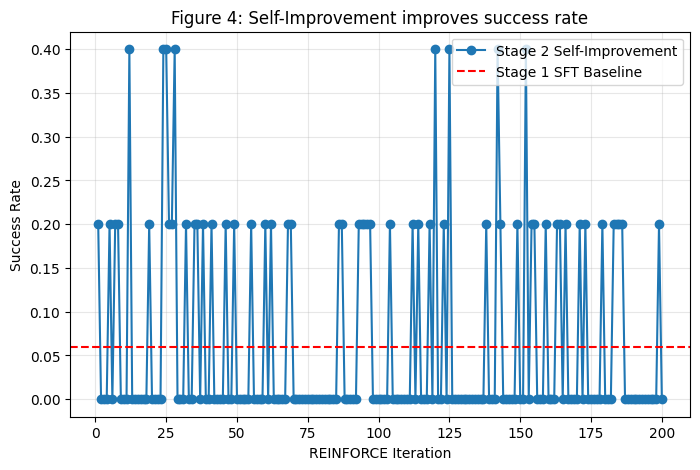

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(success_rates)+1), success_rates, marker='o', label='Stage 2 Self-Improvement')
plt.axhline(y=sft_success, color='r', linestyle='--', label='Stage 1 SFT Baseline')
plt.xlabel('REINFORCE Iteration')
plt.ylabel('Success Rate')
plt.title('Figure 4: Self-Improvement improves success rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()